# DDPM From Scratch on a 2D Toy Distribution

We train a minimal **Denoising Diffusion Probabilistic Model** (Ho, Jain, Abbeel, 2020) on a 2D toy dataset (`make_moons`). Working in 2D keeps the model tiny and CPU-fast while exposing every moving part of a diffusion model: the noise schedule, the simplified training objective, and ancestral sampling.

**Forward process.** We gradually corrupt a clean point `x_0` into pure Gaussian noise over `T` steps using a variance schedule `beta_t`:

    q(x_t | x_{t-1}) = N(x_t; sqrt(1 - beta_t) x_{t-1}, beta_t I)

Define `alpha_t = 1 - beta_t` and `abar_t = prod_{s<=t} alpha_s`. The handy closed form lets us jump straight to any timestep:

    x_t = sqrt(abar_t) * x_0 + sqrt(1 - abar_t) * eps,   eps ~ N(0, I)

**Reverse process.** A network `eps_theta(x_t, t)` learns to predict the noise `eps` that was added. Sampling runs the learned reverse chain from noise back to data (ancestral sampling).

Everything below runs on CPU in well under 90 seconds.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cpu')
print('torch', torch.__version__, '| device', device)

torch 2.12.0+cpu | device cpu


## 1. Data: two moons, standardized

We draw ~4000 points from `make_moons` with light noise, then standardize to roughly unit scale (zero mean, unit std per axis). Standardizing matters because the forward process pushes data toward a standard Gaussian; if the data already lives near unit scale, the network has an easier target.

data shape (4000, 2) | mean [ 9.059906e-09 -5.464554e-07] | std [1.0001249 1.0001249]


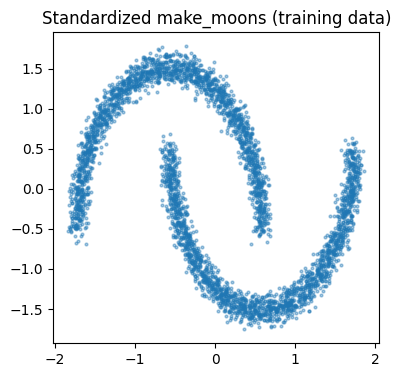

In [2]:
N = 4000
X, _ = make_moons(n_samples=N, noise=0.05, random_state=0)
X = X.astype(np.float32)
mean = X.mean(axis=0, keepdims=True)
std = X.std(axis=0, keepdims=True)
X = (X - mean) / std
data = torch.from_numpy(X)
print('data shape', tuple(data.shape), '| mean', data.mean(0).numpy(),
      '| std', data.std(0).numpy())

plt.figure(figsize=(4, 4))
plt.scatter(X[:, 0], X[:, 1], s=4, alpha=0.4)
plt.title('Standardized make_moons (training data)')
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

## 2. Noise schedule

We use a **linear beta schedule** with `T = 200` steps, the classic choice from the original DDPM paper. `beta_t` ramps linearly from a small value near `t=0` to a larger value near `t=T`. From it we precompute the cumulative products `abar_t` and their square roots, which the closed-form forward and the reverse sampler both need.

Index convention: arrays are length `T`, indexed `t = 0 .. T-1`, where `t=0` is the lightest noise level and `t=T-1` the heaviest.

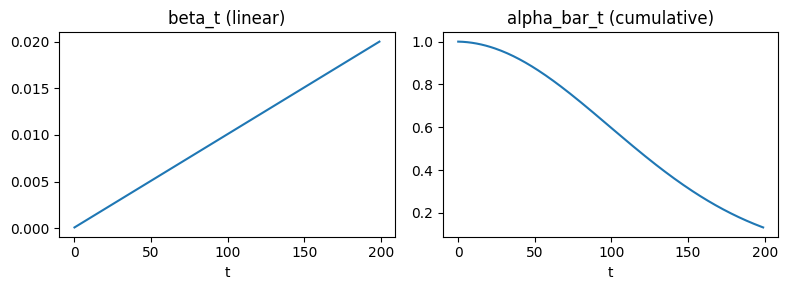

In [3]:
T = 200
beta = torch.linspace(1e-4, 0.02, T)          # linear schedule
alpha = 1.0 - beta
abar = torch.cumprod(alpha, dim=0)            # alpha_bar_t
sqrt_abar = torch.sqrt(abar)
sqrt_one_minus_abar = torch.sqrt(1.0 - abar)

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].plot(beta.numpy())
ax[0].set_title('beta_t (linear)')
ax[0].set_xlabel('t')
ax[1].plot(abar.numpy())
ax[1].set_title('alpha_bar_t (cumulative)')
ax[1].set_xlabel('t')
plt.tight_layout()
plt.show()

## 3. Model: MLP eps_theta with sinusoidal time embedding

The network predicts the noise `eps` given a noisy point `x_t` and its timestep `t`. The timestep is a scalar, so we lift it into a richer **sinusoidal embedding** (the same positional-encoding trick from Transformers) and concatenate it with the 2D point. A small MLP (width ~128, 3 hidden layers) then maps the concatenation to a 2D noise prediction.

Conditioning on `t` is essential: the right denoising direction depends on how noisy the input currently is.

In [4]:
def timestep_embedding(t, dim=64):
    # t: LongTensor of shape (B,). Returns (B, dim) sinusoidal features.
    half = dim // 2
    freqs = torch.exp(
        -np.log(10000.0) * torch.arange(half, dtype=torch.float32) / half
    )
    args = t.float()[:, None] * freqs[None, :]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=1)


class EpsMLP(nn.Module):
    def __init__(self, t_dim=64, hidden=128):
        super().__init__()
        self.t_dim = t_dim
        self.net = nn.Sequential(
            nn.Linear(2 + t_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, t):
        temb = timestep_embedding(t, self.t_dim)
        return self.net(torch.cat([x, temb], dim=1))


model = EpsMLP().to(device)
n_params = sum(p.numel() for p in model.parameters())
print('model parameters:', n_params)

model parameters: 41858


## 4. Training with L_simple

DDPM's **simplified objective** drops the variational weighting and just asks the network to predict the injected noise with an MSE loss. Per step:

1. Sample a minibatch of clean points `x_0`.
2. Sample timesteps `t ~ Uniform{0, ..., T-1}` and noise `eps ~ N(0, I)`.
3. Form the noisy point via the closed form
   `x_t = sqrt(abar_t) * x_0 + sqrt(1 - abar_t) * eps`.
4. Minimize `|| eps - eps_theta(x_t, t) ||^2`.

We train for ~2500 steps with Adam (lr 1e-3), batch size 256. This is tiny and finishes in a few seconds on CPU.

In [5]:
steps = 2500
batch = 256
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

losses = []
model.train()
for step in range(steps):
    idx = torch.randint(0, data.shape[0], (batch,))
    x0 = data[idx]
    t = torch.randint(0, T, (batch,))
    eps = torch.randn_like(x0)
    xt = sqrt_abar[t][:, None] * x0 + sqrt_one_minus_abar[t][:, None] * eps
    eps_pred = model(xt, t)
    loss = ((eps - eps_pred) ** 2).mean()
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if (step + 1) % 500 == 0:
        recent = np.mean(losses[-100:])
        print(f'step {step + 1:5d} | loss(last100) {recent:.4f}')

print('final loss(last100):', np.mean(losses[-100:]))

step   500 | loss(last100) 0.5778


step  1000 | loss(last100) 0.5364


step  1500 | loss(last100) 0.5304


step  2000 | loss(last100) 0.5189


step  2500 | loss(last100) 0.5133
final loss(last100): 0.5132552871108055


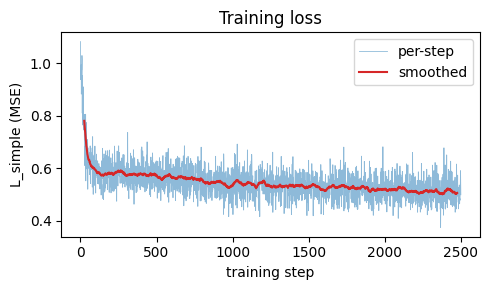

In [6]:
plt.figure(figsize=(5, 3))
plt.plot(losses, lw=0.6, alpha=0.5, label='per-step')
kern = np.ones(50) / 50
smooth = np.convolve(losses, kern, mode='valid')
plt.plot(np.arange(len(smooth)) + 25, smooth, color='C3', label='smoothed')
plt.xlabel('training step')
plt.ylabel('L_simple (MSE)')
plt.title('Training loss')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Ancestral sampling

To generate, we reverse the chain. Start from pure noise `x_T ~ N(0, I)` and step down `t = T-1, ..., 0`. At each step the network's noise prediction gives the posterior mean, and we add fresh Gaussian noise (except at the final step):

    mean = (1/sqrt(alpha_t)) * (x_t - (beta_t / sqrt(1 - abar_t)) * eps_theta)
    x_{t-1} = mean + sqrt(beta_t) * z,   z ~ N(0, I)  (z = 0 at t = 0)

We record the full trajectory so the bonus cell can visualize how a few points travel from noise to data.

In [7]:
@torch.no_grad()
def sample(model, n, record_traj=False):
    model.eval()
    x = torch.randn(n, 2)
    traj = [x.clone()] if record_traj else None
    for ti in reversed(range(T)):
        t = torch.full((n,), ti, dtype=torch.long)
        eps_pred = model(x, t)
        coef = beta[ti] / sqrt_one_minus_abar[ti]
        mean = (x - coef * eps_pred) / torch.sqrt(alpha[ti])
        if ti > 0:
            z = torch.randn_like(x)
            x = mean + torch.sqrt(beta[ti]) * z
        else:
            x = mean
        if record_traj:
            traj.append(x.clone())
    if record_traj:
        return x, torch.stack(traj)  # (T+1, n, 2)
    return x


gen = sample(model, 2000).numpy()
print('generated shape', gen.shape)

generated shape (2000, 2)


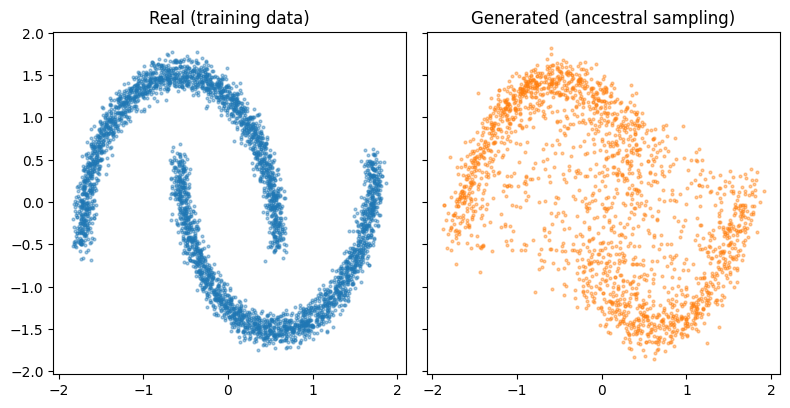

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
ax[0].scatter(X[:, 0], X[:, 1], s=4, alpha=0.4, color='C0')
ax[0].set_title('Real (training data)')
ax[0].set_aspect('equal')
ax[1].scatter(gen[:, 0], gen[:, 1], s=4, alpha=0.4, color='C1')
ax[1].set_title('Generated (ancestral sampling)')
ax[1].set_aspect('equal')
plt.tight_layout()
plt.show()

## Bonus: reverse trajectories

Below we sample just 5 points and plot how each one moves across the reverse process, from `x_T` (pure noise, faded) to `x_0` (final sample, solid). Each colored path is one point's journey; the gray cloud is the real data for reference. You should see the points drift from a diffuse Gaussian blob toward the two-moons manifold.

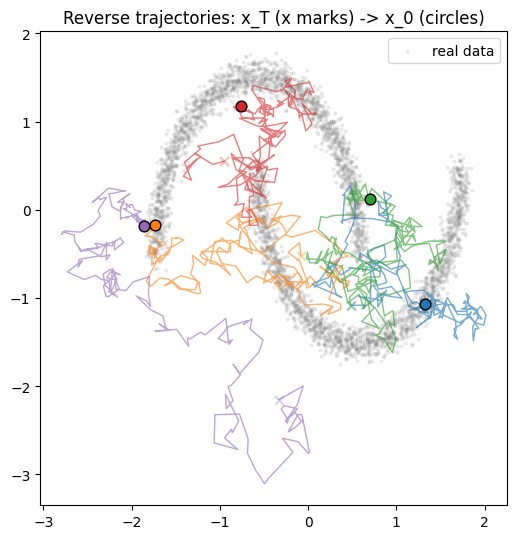

In [9]:
x0_final, traj = sample(model, 5, record_traj=True)
traj = traj.numpy()  # (T+1, 5, 2)
n_steps = traj.shape[0]

plt.figure(figsize=(5.5, 5.5))
plt.scatter(X[:, 0], X[:, 1], s=4, alpha=0.12, color='gray',
            label='real data')
for p in range(traj.shape[1]):
    path = traj[:, p, :]
    plt.plot(path[:, 0], path[:, 1], lw=1.0, alpha=0.6, color=f'C{p}')
    plt.scatter(path[0, 0], path[0, 1], s=40, color=f'C{p}',
                alpha=0.3, marker='x')          # start (noise)
    plt.scatter(path[-1, 0], path[-1, 1], s=60, color=f'C{p}',
                edgecolor='k', zorder=5)        # end (sample)
plt.title('Reverse trajectories: x_T (x marks) -> x_0 (circles)')
plt.gca().set_aspect('equal')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Takeaways

- The whole DDPM recipe fits in a tiny MLP once you work in 2D: a linear   beta schedule, the closed-form forward jump, and an MSE noise-prediction   loss (`L_simple`).
- Ancestral sampling reconstructs the data manifold from pure noise by   iteratively subtracting predicted noise.
- The reverse trajectories make the generative process tangible: random   starts collapse onto the two moons.

Natural next steps: try a cosine schedule, compare DDIM (deterministic) sampling, or condition the model on a class label for the two moons.